## create_agent, the agent layer

In [59]:
from dotenv import load_dotenv
from IPython.display import Image, display
from pydantic import BaseModel, Field

from langchain.agents import create_agent
from langchain.agents.middleware import wrap_tool_call
from langchain_core.tools import tool

from langgraph.checkpoint.memory import MemorySaver
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain_mcp_adapters.tools import load_mcp_tools

load_dotenv(override=True)

True

In [42]:
agent = create_agent(
    model = "openai:gpt-4.1-nano",
    system_prompt = "You are a helpful assistant who answers concisely."
)

result = agent.invoke({
    "messages": [{
        "role": "user",
        "content": "What is the Model Context Protocol, in two sentences?"
    }]
})

print(result["messages"][-1].content)

The Model Context Protocol is a framework for managing and exchanging contextual information within AI and machine learning models to improve their understanding and responsiveness. It enables models to maintain relevant background data dynamically, enhancing their ability to generate context-aware outputs.


In [43]:
result = await agent.ainvoke({"messages": [{
    "role": "user",
    "content": "In one sentence: why does async code suit agents so well?"
}]})

print(result["messages"][-1].content)

Async code suits agents well because it enables them to handle multiple concurrent tasks efficiently without blocking, allowing for responsive and scalable operations.


In [44]:
@tool
def get_weather(city: str) -> str:
    """Return today's weather for a city."""
    pretend = {"London": "rainy, 14 degrees", "Rome": "sunny, 27 degrees"}
    return pretend.get(city, "clear, 20 degrees")

@tool
def get_population(city: str) -> str:
    """Return the population of a city."""
    pretend = {"London": "8.9 million", "Rome": "2.8 million"}
    return pretend.get(city, "unknown")

agent = create_agent(
    model = "openai:gpt-4.1-nano",
    tools = [get_weather, get_population],
    system_prompt = "You are a travel assistant. Use you tools to answer questions about cities."
)

result = agent.invoke({
    "messages": [{
        "role": "user",
        "content": "What is the weather and population of Rome?"
    }]
})

print(result["messages"][-1].content)

The weather in Rome is sunny with a temperature of 27 degrees Celsius. The population of Rome is approximately 2.8 million.


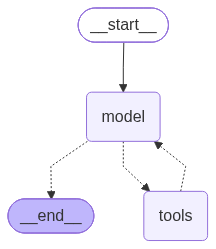

In [45]:
display(Image(agent.get_graph().draw_mermaid_png()))

In [46]:
memory_agent = create_agent(
    model="openai:gpt-4.1-nano",
    tools=[get_weather],
    checkpointer=MemorySaver(),
)

config = {
    "configurable": {
        "thread_id": "trip-planning"
    }
}

memory_agent.invoke({
    "messages": [{
        "role": "user",
        "content": "I am planning a trip to London.",
    }]
}, config=config)

result = memory_agent.invoke({
    "messages": [{
        "role": "user",
        "content": "What is the weather like where I am going on my trip?"
    }]
}, config=config)

print(result["messages"][-1].content)

The weather in London is rainy with a temperature of around 14 degrees Celsius. Be sure to pack an umbrella and some rain gear for your trip!


In [47]:
class CityReport(BaseModel):
    city: str = Field(description="The city name")
    weather: str = Field(description="A short weather description")
    population: str = Field(description="The population")

report_agent = create_agent(
    model="openai:gpt-4.1-nano",
    tools=[get_weather, get_population],
    response_format=CityReport,
)

result = report_agent.invoke({
    "messages": [{
        "role": "user",
        "content": "Give me a report on London."
    }]
})

report = result["structured_response"]
print(report)
print("Just the weather:", report.weather)

city='London' weather='rainy, 14 degrees' population='8.9 million'
Just the weather: rainy, 14 degrees


In [48]:
@wrap_tool_call
def log_tool_calls(request, handler):
    call = request.tool_call
    print(f"  [middleware] calling {call['name']} with {call['args']}")
    return handler(request)

watch_agent = create_agent(
    model="openai:gpt-4.1-nano",
    tools=[get_weather, get_population],
    system_prompt="You are a travel assistant. Use your tools",
    middleware=[log_tool_calls],
)

result = watch_agent.invoke({
    "messages": [{
        "role": "user",
        "content": "Weather and population of London and Rome?"
    }]
})

print(result["messages"][-1].content)

  [middleware] calling get_weather with {'city': 'London'}
  [middleware] calling get_population with {'city': 'London'}
  [middleware] calling get_weather with {'city': 'Rome'}
  [middleware] calling get_population with {'city': 'Rome'}
The current weather in London is rainy with a temperature of 14°C, and the population is approximately 8.9 million. In Rome, it is sunny with a temperature of 27°C, and the population is about 2.8 million.


In [49]:
!node --version
!npx --version

v24.16.0
11.13.0


In [50]:
!npx playwright install chrome

⠙⠹⠸⠼⠴⠦╔═══════════════════════════════════════════════════════════════════════════════╗
║ WARNING: It looks like you are running 'npx playwright install' without first ║
║ installing your project's dependencies.                                       ║
║                                                                               ║
║ To avoid unexpected behavior, please install your dependencies first, and     ║
║ then run Playwright's install command:                                        ║
║                                                                               ║
║     npm install                                                               ║
║     npx playwright install                                                    ║
║                                                                               ║
║ If your project does not yet depend on Playwright, first install the          ║
║ applicable npm package (most commonly @playwright/test), and                  ║
║ then run

⠙⠹⠸⠼⠴⠦⠧Navigating to https://news.ycombinator.com
Capturing screenshot into playwright_check.png
⠙

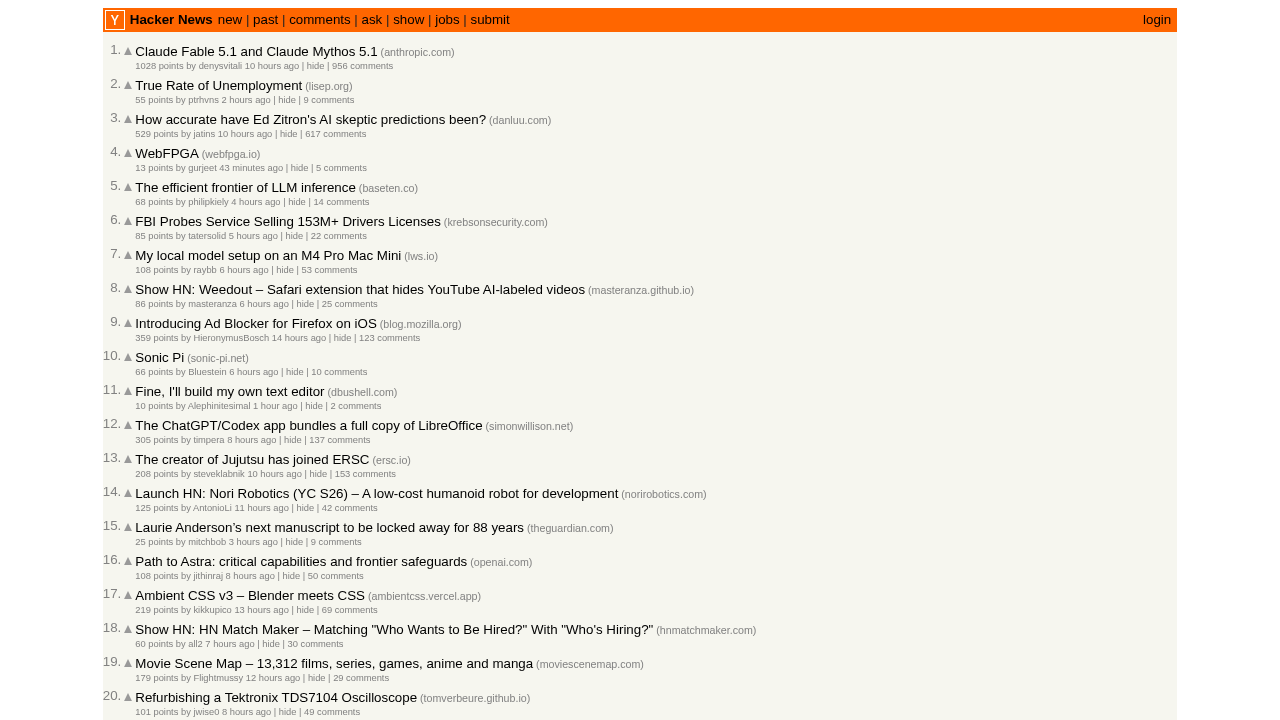

In [51]:
!npx -y playwright@latest screenshot --channel=chrome https://news.ycombinator.com playwright_check.png
display(Image("playwright_check.png"))

In [52]:
import sys

if sys.platform == "win32":
    import subprocess
    from functools import partial
    import langchain_mcp_adapters.sessions as mcp_sessions

    mcp_sessions.stdio_client = partial(mcp_sessions.stdio_client, errlog=subprocess.DEVNULL)
    print("Applied the Windows adjustment")
else:
    print("Not Windows, so nothing to do here")

Not Windows, so nothing to do here


In [ ]:
client = MultiServerMCPClient({
    "playwright": {
        "transport": "stdio",
        "command": "npx",
        "args": ["-y", "@playwright/mcp@latest"],
    }
})

browser_tools = await client.get_tools()
print(f"Loaded {len(browser_tools)} browser tools:")
for t in browser_tools:
    print(" -", t.name)

Loaded 24 browser tools:
 - browser_close
 - browser_resize
 - browser_console_messages
 - browser_handle_dialog
 - browser_evaluate
 - browser_file_upload
 - browser_drop
 - browser_find
 - browser_fill_form
 - browser_press_key
 - browser_type
 - browser_navigate
 - browser_navigate_back
 - browser_network_requests
 - browser_network_request
 - browser_run_code_unsafe
 - browser_take_screenshot
 - browser_snapshot
 - browser_click
 - browser_drag
 - browser_hover
 - browser_select_option
 - browser_tabs
 - browser_wait_for


In [ ]:
async with client.session("playwright") as session:

    browser_tools = await load_mcp_tools(session)

    print(f"Loaded {len(browser_tools)} browser tools:")
    for tool in browser_tools:
        print(" -", tool.name)

    browser_agent = create_agent(
        model="openai:gpt-4.1-nano",
        tools=browser_tools,
        system_prompt="""
            You are a web research assistant.

            Use the Playwright browser tools to research websites.

            When performing web research:
            1. Navigate to the requested URL.
            2. Inspect the page using browser_snapshot or another appropriate
            browser inspection tool.
            3. Extract information from the live webpage.
            4. Never guess information from your training data.
            5. Clearly report the results to the user.
            """
    )

    result = await browser_agent.ainvoke({
        "messages": [{
            "role": "user",
            "content": """
                Go to https://news.ycombinator.com and tell me
                the titles of the top three stories on the front page.
                """
        }]
    })

    print(result["messages"][-1].content)

Loaded 24 browser tools:
 - browser_close
 - browser_resize
 - browser_console_messages
 - browser_handle_dialog
 - browser_evaluate
 - browser_file_upload
 - browser_drop
 - browser_find
 - browser_fill_form
 - browser_press_key
 - browser_type
 - browser_navigate
 - browser_navigate_back
 - browser_network_requests
 - browser_network_request
 - browser_run_code_unsafe
 - browser_take_screenshot
 - browser_snapshot
 - browser_click
 - browser_drag
 - browser_hover
 - browser_select_option
 - browser_tabs
 - browser_wait_for
The titles of the top three stories on the front page of Hacker News are:

1. "Claude Fable 5.1 and Claude Mythos 5.1" from anthropic.com
2. "The Emergent Symbolic Structure of Artificial Neural Networks" from arxiv.org
3. "How accurate have Ed Zitron's AI skeptic predictions been?" from danluu.com
